Previsor de Partidas de League of Legends
Introdução
League of Legends, um popular jogo do gênero multiplayer online battle arena (MOBA), gera uma grande quantidade de dados a partir das partidas, oferecendo uma excelente oportunidade para aplicar técnicas de aprendizado de máquina em cenários do mundo real.

Siga as etapas abaixo para construir um modelo de regressão logística com o objetivo de prever os resultados das partidas de League of Legends.

Use o arquivo league_of_legends_data_large.csv para realizar as tarefas.

Etapa 1: Carregamento e Pré-processamento dos Dados
Tarefa 1: Carregar o conjunto de dados de League of Legends e prepará-lo para o treinamento
O carregamento e o pré-processamento do conjunto de dados envolvem ler os dados, dividi-los em conjuntos de treino e teste, e padronizar as variáveis (features).

Serão utilizadas as seguintes bibliotecas:

pandas para manipulação de dados
train_test_split de sklearn.model_selection para dividir o conjunto de dados
StandardScaler de sklearn.preprocessing para normalizar as variáveis
Observação: Certifique-se de que todas as bibliotecas necessárias estão instaladas e importadas.

Passos:
Carregar o conjunto de dados:
Use pd.read_csv() para carregar o dataset em um DataFrame do pandas.

Separar variáveis e rótulo (target):
Separe a coluna win (variável alvo) das demais colunas (features):

X = data.drop('win', axis=1)
y = data['win']
Configuração
Instalação das bibliotecas necessárias
As seguintes bibliotecas não estão pré-instaladas no ambiente do Skills Network Labs.
Você precisará executar a célula abaixo para instalá-las:

!pip install pandas scikit-learn torch



In [8]:
# %%time
# %pip install pandas scikit-learn matplotlib
# %pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
#     --index-url https://download.pytorch.org/whl/cpu

In [9]:
import pandas as pd

df = pd.read_csv("./league_of_legends_data_large (2).csv")

df.head()

,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
0,0,16,6,19,17088,231,11,7,15367
1,1,8,8,5,14865,259,10,2,38332
2,0,0,17,11,15919,169,14,5,24642
3,0,19,11,1,11534,264,14,3,15789
4,0,12,7,6,18926,124,15,7,40268


In [10]:
df.describe()

,win,kills,deaths,assists,gold_earned,cs,wards_placed,wards_killed,damage_dealt
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,0.51000,9.332000,9.487000,9.395000,12433.808000,181.21300,9.834000,4.541000,27484.905000
std,0.50015,5.798569,5.773488,5.765086,4388.138751,72.11491,5.739633,2.906332,13221.571932
min,0.00000,0.000000,0.000000,0.000000,5002.000000,50.00000,0.000000,0.000000,5028.000000
25%,0.00000,4.000000,4.000000,4.000000,8551.750000,121.00000,5.000000,2.000000,15759.000000
50%,1.00000,9.000000,9.000000,10.000000,12295.000000,183.50000,10.000000,5.000000,27370.000000
75%,1.00000,14.000000,14.000000,14.000000,16348.250000,243.00000,15.000000,7.000000,39453.000000
max,1.00000,19.000000,19.000000,19.000000,19955.000000,299.00000,19.000000,9.000000,49927.000000


Etapa 2: Modelo de Regressão Logística
Tarefa 2: Implementar um modelo de regressão logística usando PyTorch
Definir o modelo de regressão logística envolve especificar as dimensões de entrada, a passagem forward utilizando a função de ativação sigmoid, e inicializar o modelo, a função de perda e o otimizador.

Passos:
Definir o Modelo de Regressão Logística:

Crie uma classe LogisticRegressionModel que herda de torch.nn.Module.
No método __init__(), defina uma camada linear (nn.Linear) para implementar o modelo de regressão logística.
No método forward(), aplique a função de ativação sigmoid ao resultado da camada linear.
Inicializar o Modelo, a Função de Perda e o Otimizador:

input_dim: use X_train.shape[1] para obter o número de features (variáveis de entrada) a partir dos dados de treinamento X_train.
Inicialização do modelo: crie uma instância da classe LogisticRegressionModel, passando input_dim como parâmetro, por exemplo:
model = LogisticRegressionModel(input_dim)
Função de perda: utilize BCELoss() de torch.nn (Perda Binária de Entropia Cruzada).
Otimizador: inicialize o otimizador utilizando optim.SGD() com taxa de aprendizado (lr) igual a 0.01.
Exercício 2
Defina o modelo de regressão logística utilizando PyTorch, especificando:

As dimensões de entrada
A passagem forward com a função sigmoid
A inicialização do modelo, da função de perda e do otimizador



In [11]:
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Definindo o modelo de Regressão Logística
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        outputs = torch.sigmoid(self.linear(x))
        return outputs

# Assegurar que df esteja definido (assumindo que a célula anterior de carregamento de dados foi executada)
# Se 'df' não estiver definido, descomente a linha abaixo:
# df = pd.read_csv("/content/league_of_legends_data_large (2).csv")

# Separar variáveis e target
X = df.drop('win', axis=1)
y = df['win']

# Dividir o dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar as features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Converter para tensores do pytorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Inicializando o modelo, Loss function e Otimização
input_dim = X_train.shape[1] # Número de features em X_train
model = LogisticRegressionModel(input_dim)
criterion = nn.BCELoss() # Binary Cross-Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Separar variáveis e target
X = df.drop('win', axis=1)
y = df['win']

# Dividir o dataset em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar as features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Converter para tensores do pytorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1) # Reshape to (n_samples, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1) # Reshape to (n_samples, 1)

Etapa 3: Treinamento do Modelo
Tarefa 3: Treinar o modelo de regressão logística no conjunto de dados
O processo de treinamento será executado por um número definido de épocas (epochs).
Em cada época, o modelo fará previsões, calculará a perda, realizará a retropropagação (backpropagation) e atualizará os parâmetros.

Passos:
Definir o número de épocas:

Configure o número de épocas de treinamento como 1000.
Laço de Treinamento:
Para cada época:

Coloque o modelo em modo de treinamento usando model.train().
Zere os gradientes com optimizer.zero_grad().
Passe os dados de treinamento (X_train) pelo modelo para obter as previsões (outputs).
Calcule a perda usando a função de perda definida (criterion).
Realize a retropropagação com loss.backward().
Atualize os pesos do modelo com optimizer.step().
Exibir a perda a cada 100 épocas:

A cada 100 épocas, imprima o número da época e o valor atual da perda (loss).
Avaliação do Modelo:

Coloque o modelo em modo de avaliação usando model.eval().
Utilize torch.no_grad() para garantir que os gradientes não sejam calculados durante a avaliação.
Obtenha as previsões tanto para o conjunto de treinamento (X_train) quanto para o conjunto de teste (X_test).
Calcular a Acurácia:

Para ambos os conjuntos (treino e teste), calcule a acurácia comparando os valores previstos com os verdadeiros (y_train, y_test).
Use o limiar (threshold) de 0.5 para classificar as saídas.
Exibir a Acurácia:

Imprima as acurácias de treinamento e teste após a avaliação do modelo.
Exercício 3
Escreva o código para treinar o modelo de regressão logística no conjunto de dados.
Implemente o laço de treinamento, incluindo:

Predição,
Cálculo da perda,
Retropropagação (backpropagation),
Atualização dos parâmetros do modelo.
Em seguida, avalie a acurácia do modelo nos conjuntos de treinamento e teste.



In [13]:
num_epochs = 1000

for epoch in range(num_epochs):
    model.train() # sem argumentos
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluation
model.eval()
with torch.no_grad():
    # Predictions on training set
    train_outputs = model(X_train)
    train_predicted = (train_outputs > 0.5).float()
    train_accuracy = (train_predicted == y_train).sum().item() / y_train.size(0)

    # Predictions on test set
    test_outputs = model(X_test)
    test_predicted = (test_outputs > 0.5).float()
    test_accuracy = (test_predicted == y_test).sum().item() / y_test.size(0)

print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

Epoch [100/1000], Loss: 0.7385
Epoch [200/1000], Loss: 0.7171
Epoch [300/1000], Loss: 0.7041
Epoch [400/1000], Loss: 0.6964
Epoch [500/1000], Loss: 0.6918
Epoch [600/1000], Loss: 0.6891
Epoch [700/1000], Loss: 0.6875
Epoch [800/1000], Loss: 0.6866
Epoch [900/1000], Loss: 0.6861
Epoch [1000/1000], Loss: 0.6857
Training Accuracy: 0.5525
Test Accuracy: 0.5050


Epoch [100/1000], Loss: 0.7151
Epoch [200/1000], Loss: 0.7039
Epoch [300/1000], Loss: 0.6968
Epoch [400/1000], Loss: 0.6924
Epoch [500/1000], Loss: 0.6896
Epoch [600/1000], Loss: 0.6879
Epoch [700/1000], Loss: 0.6869
Epoch [800/1000], Loss: 0.6863
Epoch [900/1000], Loss: 0.6859
Epoch [1000/1000], Loss: 0.6856
Training Accuracy: 0.5437
Test Accuracy: 0.5300



Etapa 4: Otimização e Avaliação do Modelo
Tarefa 4: Implementar técnicas de otimização e avaliar o desempenho do modelo
Técnicas de otimização, como a regularização L2 (Ridge Regression), ajudam a prevenir o overfitting.
O modelo será novamente treinado com essas otimizações, e seu desempenho será avaliado nos conjuntos de treinamento e teste.

Conceito de Weight Decay
No contexto do aprendizado de máquina, e especificamente em algoritmos de otimização, o parâmetro weight_decay é utilizado para aplicar regularização L2 aos pesos do modelo.

Ele atua penalizando valores de pesos muito grandes, o que ajuda o modelo a evitar o overfitting e a encontrar soluções mais simples e generalizáveis.

Durante a inicialização do otimizador, a regularização L2 é adicionada ao processo de atualização dos parâmetros.



In [14]:
# Inicializando um novo modelo e otimizando com weight decay (L2 regularization)
model_optimized = LogisticRegressionModel(input_dim)
criterion_optimized = nn.BCELoss()
# Apply L2 regularization using weight_decay in the optimizer
optimizer_optimized = optim.SGD(model_optimized.parameters(), lr=0.01, weight_decay=0.001) # weight_decay adicionado

num_epochs_optimized = 1000

print("\n--- Training with L2 Regularization ---")
for epoch in range(num_epochs_optimized):
    model_optimized.train()
    optimizer_optimized.zero_grad()
    outputs_optimized = model_optimized(X_train)
    loss_optimized = criterion_optimized(outputs_optimized, y_train)
    loss_optimized.backward()
    optimizer_optimized.step()

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_optimized}], Loss: {loss_optimized.item():.4f}')

# Avaliando o modelo otimizado
model_optimized.eval()
with torch.no_grad():
    # Predições do treino para o modelo otimizado
    train_outputs_optimized = model_optimized(X_train)
    train_predicted_optimized = (train_outputs_optimized > 0.5).float()
    train_accuracy_optimized = (train_predicted_optimized == y_train).sum().item() / y_train.size(0)

    # Predições do teste para o modelo otimizado
    test_outputs_optimized = model_optimized(X_test)
    test_predicted_optimized = (test_outputs_optimized > 0.5).float()
    test_accuracy_optimized = (test_predicted_optimized == y_test).sum().item() / y_test.size(0)

print(f'\nOptimized Model Training Accuracy: {train_accuracy_optimized:.4f}')
print(f'Optimized Model Test Accuracy: {test_accuracy_optimized:.4f}')


--- Training with L2 Regularization ---
Epoch [100/1000], Loss: 0.7132
Epoch [200/1000], Loss: 0.7025
Epoch [300/1000], Loss: 0.6959
Epoch [400/1000], Loss: 0.6917
Epoch [500/1000], Loss: 0.6892
Epoch [600/1000], Loss: 0.6877
Epoch [700/1000], Loss: 0.6867
Epoch [800/1000], Loss: 0.6862
Epoch [900/1000], Loss: 0.6858
Epoch [1000/1000], Loss: 0.6856

Optimized Model Training Accuracy: 0.5300
Optimized Model Test Accuracy: 0.5100


--- Training with L2 Regularization ---
Epoch [100/1000], Loss: 0.7354
Epoch [200/1000], Loss: 0.7160
Epoch [300/1000], Loss: 0.7040
Epoch [400/1000], Loss: 0.6967
Epoch [500/1000], Loss: 0.6922
Epoch [600/1000], Loss: 0.6895
Epoch [700/1000], Loss: 0.6878
Epoch [800/1000], Loss: 0.6868
Epoch [900/1000], Loss: 0.6862
Epoch [1000/1000], Loss: 0.6858

Optimized Model Training Accuracy: 0.5337
Optimized Model Test Accuracy: 0.5050



Etapa 5: Visualização e Interpretação
Ferramentas de visualização, como matrizes de confusão e curvas ROC, fornecem uma visão mais profunda sobre o desempenho do modelo.
A matriz de confusão ajuda a entender a precisão das classificações, enquanto a curva ROC ilustra o equilíbrio entre sensibilidade e especificidade.

📊 Matriz de Confusão
A Matriz de Confusão é uma ferramenta fundamental usada em problemas de classificação para avaliar o desempenho de um modelo.
Ela mostra o número de previsões corretas e incorretas feitas pelo modelo, categorizadas pelas classes reais e previstas.

Tipo	Descrição
True Positive (TP)	Classe positiva corretamente prevista (classe 1)
True Negative (TN)	Classe negativa corretamente prevista (classe 0)
False Positive (FP)	Previsto como positivo (classe 1), mas a classe real é negativa (classe 0) — Erro Tipo I
False Negative (FN)	Previsto como negativo (classe 0), mas a classe real é positiva (classe 1) — Erro Tipo II
📈 Curva ROC (Receiver Operating Characteristic)
A Curva ROC é uma representação gráfica usada para avaliar o desempenho de um modelo de classificação binária em diferentes limiares de decisão.
Ela relaciona duas métricas importantes:

True Positive Rate (TPR) ou Recall / Sensibilidade — proporção de exemplos realmente positivos classificados corretamente.
False Positive Rate (FPR) — proporção de exemplos negativos classificados incorretamente como positivos.
🔵 AUC (Area Under the Curve)
O AUC é a Área Sob a Curva ROC e representa uma métrica de desempenho global do modelo de classificação.
Quanto maior o valor do AUC (próximo de 1), melhor o modelo consegue distinguir entre as classes positiva e negativa.

📋 Relatório de Classificação (Classification Report)
O Classification Report é um resumo com várias métricas de desempenho do classificador, incluindo:

Precisão (Precision)
Revocação (Recall)
Pontuação F1 (F1-Score)
Essas métricas são úteis para avaliar o desempenho geral do modelo em cada classe.

🧩 Exercício 5
Escreva o código para visualizar o desempenho do modelo utilizando:

Matrizes de confusão
Curvas ROC
Relatórios de classificação (Precision, Recall e F1-score)
Reentreine o modelo com regularização L2 e avalie o desempenho utilizando essas métricas.



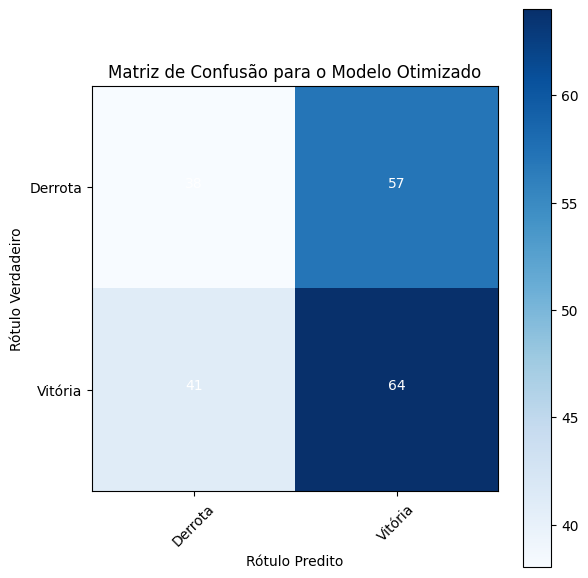

Relatório de Classificação para o Modelo Otimizado:
               precision    recall  f1-score   support

     Derrota       0.48      0.40      0.44        95
     Vitória       0.53      0.61      0.57       105

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.51      0.51      0.50       200



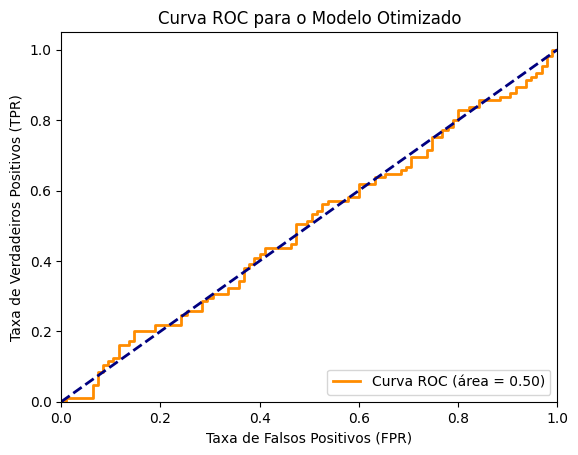

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools
import numpy as np

# Certifique-se de que o modelo otimizado está em modo de avaliação
model_optimized.eval()

# Obter as previsões do modelo otimizado no conjunto de teste
with torch.no_grad():
    # test_outputs_optimized são as probabilidades (já calculadas na célula anterior)
    # test_predicted_optimized são as classes binárias (já calculadas na célula anterior)
    y_pred_proba = test_outputs_optimized.cpu().numpy()
    y_pred_labels = test_predicted_optimized.cpu().numpy()
    y_true_labels = y_test.cpu().numpy()

# 📊 Matriz de Confusão
cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão para o Modelo Otimizado')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Derrota', 'Vitória'], rotation=45)
plt.yticks(tick_marks, ['Derrota', 'Vitória'])

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.show()

# 📋 Relatório de Classificação
print("Relatório de Classificação para o Modelo Otimizado:\n", 
      classification_report(y_true_labels, y_pred_labels, target_names=['Derrota', 'Vitória']))

# 📈 Curva ROC
fpr, tpr, thresholds = roc_curve(y_true_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC para o Modelo Otimizado')
plt.legend(loc="lower right")
plt.show()

Double-click here for the Hint.



Etapa 6: Salvamento e Carregamento do Modelo
Tarefa 6: Salvar e carregar o modelo treinado
Nesta etapa, você aprenderá a persistir um modelo treinado usando torch.save e a recarregá-lo usando torch.load.
Avaliar o modelo carregado garante que ele mantenha seu desempenho, tornando-o pronto para uso em aplicações reais.

Passos:
Salvar o Modelo:

Salve os pesos e vieses aprendidos pelo modelo usando torch.save().
Exemplo:
torch.save(model.state_dict(), 'logistic_model.pth')
Observação: Salvar apenas o state dictionary (parâmetros do modelo) é mais flexível e eficiente do que salvar o objeto do modelo inteiro.

Carregar o Modelo:

Crie uma nova instância do modelo:
model_loaded = LogisticRegressionModel(input_dim)
Carregue os parâmetros salvos:
model_loaded.load_state_dict(torch.load('logistic_model.pth'))
Avaliar o Modelo Carregado:

Coloque o modelo em modo de avaliação:
model_loaded.eval()
Utilize torch.no_grad() para garantir que nenhum gradiente seja calculado.
Avalie o modelo no conjunto de teste e verifique se o desempenho é semelhante ao do modelo original.
Exercício 6
Escreva o código para salvar o modelo treinado e recarregá-lo.
Em seguida, avalie o modelo carregado no conjunto de teste para garantir que ele funcione de forma consistente.



In [16]:
# Save the model's state dictionary
torch.save(model_optimized.state_dict(), 'logistic_model_optimized.pth')
print("Modelo otimizado salvo como 'logistic_model_optimized.pth'")

# Load the model
model_loaded = LogisticRegressionModel(input_dim)
model_loaded.load_state_dict(torch.load('logistic_model_optimized.pth'))
print("Modelo carregado com sucesso!")

# Ensure the loaded model is in evaluation mode
model_loaded.eval()

# Evaluate the loaded model
with torch.no_grad():
    test_outputs_loaded = model_loaded(X_test)
    test_predicted_loaded = (test_outputs_loaded > 0.5).float()
    test_accuracy_loaded = (test_predicted_loaded == y_test).sum().item() / y_test.size(0)

print(f'Acurácia do modelo carregado no conjunto de teste: {test_accuracy_loaded:.4f}')



Modelo otimizado salvo como 'logistic_model_optimized.pth'
Modelo carregado com sucesso!
Acurácia do modelo carregado no conjunto de teste: 0.5100


C:\Users\Admin\AppData\Local\Temp\ipykernel_33436\691136559.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loaded.load_state_dict(torch.load('logistic_model_optim

Modelo otimizado salvo como 'logistic_model_optimized.pth'
Modelo carregado com sucesso!
Acurácia do modelo carregado no conjunto de teste: 0.5050



Etapa 7: Ajuste de Hiperparâmetros
Tarefa 7: Realizar ajuste de hiperparâmetros para encontrar a melhor taxa de aprendizado
Testando diferentes taxas de aprendizado (learning rates), você poderá identificar a taxa ótima que fornece a melhor acurácia no conjunto de teste.
Este ajuste fino é essencial para melhorar o desempenho do modelo.

Passos:
Definir as Taxas de Aprendizado:

Escolha os valores a serem testados, por exemplo:
learning_rates = [0.01, 0.05, 0.1]
Reinicializar o Modelo para Cada Taxa de Aprendizado:

Para cada taxa de aprendizado, é necessário reinicializar o modelo e o otimizador, pois os parâmetros do otimizador estão vinculados à taxa de aprendizado.
Exemplo:
model = LogisticRegressionModel(input_dim)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
Treinar o Modelo para Cada Taxa de Aprendizado:

Treine o modelo por um número fixo de épocas (por exemplo, 50 ou 100) para cada taxa de aprendizado.
Calcule a acurácia no conjunto de teste.
Armazene a acurácia obtida para cada configuração.
Avaliar e Comparar:

Compare a acurácia no teste para cada taxa de aprendizado.
Identifique e reporte a taxa de aprendizado que apresenta a maior acurácia.
Exercício 7
Realize o ajuste de hiperparâmetros para encontrar a melhor taxa de aprendizado.

Reentreine o modelo para cada taxa de aprendizado.
Avalie o desempenho e identifique a taxa ótima.



In [17]:
# 1. Definir as Taxas de Aprendizado
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
num_epochs_hp_tuning = 100 # Número de épocas para cada teste de taxa de aprendizado

best_accuracy = 0
best_lr = None

print("\n--- Ajuste de Hiperparâmetros (Taxa de Aprendizado) ---")

for lr in learning_rates:
    print(f"\nTestando taxa de aprendizado (lr): {lr}")

    # 2. Reinicializar o Modelo e Otimizador para Cada Taxa de Aprendizado
    # Usamos o modelo otimizado como base, ou podemos usar um novo modelo sem weight_decay
    # Para este exercício, vamos usar um novo modelo sem weight_decay explícito aqui, focando apenas no LR
    model_hp = LogisticRegressionModel(input_dim)
    criterion_hp = nn.BCELoss()
    optimizer_hp = optim.SGD(model_hp.parameters(), lr=lr)

    # 3. Treinar o Modelo para Cada Taxa de Aprendizado
    for epoch in range(num_epochs_hp_tuning):
        model_hp.train()
        optimizer_hp.zero_grad()
        outputs_hp = model_hp(X_train)
        loss_hp = criterion_hp(outputs_hp, y_train)
        loss_hp.backward()
        optimizer_hp.step()

        # Opcional: imprimir perda a cada X épocas para acompanhar
        # if (epoch + 1) % 50 == 0:
        #     print(f'  Epoch [{epoch+1}/{num_epochs_hp_tuning}], Loss: {loss_hp.item():.4f}')

    # Avaliar o desempenho no conjunto de teste
    model_hp.eval()
    with torch.no_grad():
        test_outputs_hp = model_hp(X_test)
        test_predicted_hp = (test_outputs_hp > 0.5).float()
        current_accuracy = (test_predicted_hp == y_test).sum().item() / y_test.size(0)

    print(f'  Acurácia do modelo no teste com lr={lr}: {current_accuracy:.4f}')

    # 4. Avaliar e Comparar
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_lr = lr

print(f"\n--- Resultados do Ajuste de Hiperparâmetros ---")
print(f"Melhor Taxa de Aprendizado encontrada: {best_lr}")
print(f"Melhor Acurácia no Teste: {best_accuracy:.4f}")




--- Ajuste de Hiperparâmetros (Taxa de Aprendizado) ---

Testando taxa de aprendizado (lr): 0.001
  Acurácia do modelo no teste com lr=0.001: 0.5050

Testando taxa de aprendizado (lr): 0.005
  Acurácia do modelo no teste com lr=0.005: 0.5300

Testando taxa de aprendizado (lr): 0.01
  Acurácia do modelo no teste com lr=0.01: 0.4900

Testando taxa de aprendizado (lr): 0.05
  Acurácia do modelo no teste com lr=0.05: 0.4900

Testando taxa de aprendizado (lr): 0.1
  Acurácia do modelo no teste com lr=0.1: 0.5150

Testando taxa de aprendizado (lr): 0.5
  Acurácia do modelo no teste com lr=0.5: 0.5050

--- Resultados do Ajuste de Hiperparâmetros ---
Melhor Taxa de Aprendizado encontrada: 0.005
Melhor Acurácia no Teste: 0.5300


--- Ajuste de Hiperparâmetros (Taxa de Aprendizado) ---

Testando taxa de aprendizado (lr): 0.001
  Acurácia do modelo no teste com lr=0.001: 0.4900

Testando taxa de aprendizado (lr): 0.005
  Acurácia do modelo no teste com lr=0.005: 0.4800

Testando taxa de aprendizado (lr): 0.01
  Acurácia do modelo no teste com lr=0.01: 0.5050

Testando taxa de aprendizado (lr): 0.05
  Acurácia do modelo no teste com lr=0.05: 0.4750

Testando taxa de aprendizado (lr): 0.1
  Acurácia do modelo no teste com lr=0.1: 0.5000

Testando taxa de aprendizado (lr): 0.5
  Acurácia do modelo no teste com lr=0.5: 0.5050

--- Resultados do Ajuste de Hiperparâmetros ---
Melhor Taxa de Aprendizado encontrada: 0.01
Melhor Acurácia no Teste: 0.5050



Etapa 8: Importância das Features
Tarefa 8: Avaliar a importância das features para entender o impacto de cada variável na predição.
O código avalia a importância das features para entender o impacto de cada uma na predição.

Extraindo os Pesos do Modelo:

Os pesos do modelo de regressão logística representam a importância de cada feature nas previsões. Esses pesos estão armazenados na camada linear do modelo (model.linear.weight).
Você pode extrair os pesos usando model.linear.weight.data.numpy() e achatar o tensor resultante para obter um array 1D com a importância das features.
Criando um DataFrame:

Crie um DataFrame do pandas com duas colunas: uma para os nomes das features e outra para os valores de importância correspondentes (ou seja, os pesos aprendidos).
Certifique-se de que as features estejam alinhadas com seus nomes no dataset (por exemplo, X_train.columns).
Ordenando e Plotando a Importância das Features:

Ordene as features com base no valor absoluto de sua importância (pesos) para identificar as mais impactantes.
Utilize um gráfico de barras (via matplotlib) para visualizar as importâncias ordenadas, com os nomes das features no eixo y e os valores de importância no eixo x.
Interpretando os Resultados:

Pesos absolutos maiores indicam features mais influentes. Pesos positivos sugerem correlação positiva com o resultado (tendência a prever a classe positiva), enquanto pesos negativos sugerem o contrário.
Exercício 8:
Avalie a importância das features extraindo os pesos da camada linear e criando um DataFrame para exibir a importância de cada feature. Visualize a importância das features usando um gráfico de barras.



Importância das Features:


,Feature,Importance
3,gold_earned,0.166180
0,kills,0.126118
5,wards_placed,0.094738
2,assists,0.014609
7,damage_dealt,-0.001231
1,deaths,-0.003320
4,cs,-0.035976
6,wards_killed,-0.041077


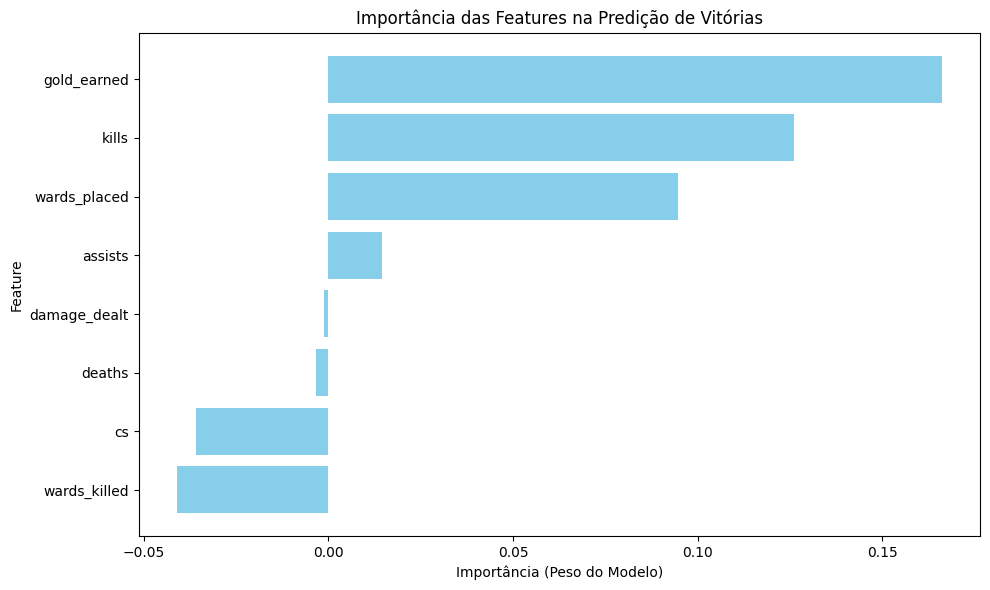

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the weights of the linear layer from the optimized model
weights = model_optimized.linear.weight.data.numpy().flatten()
features = X.columns # Get feature names from the original DataFrame X

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': features, 'Importance': weights})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print("Importância das Features:")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Importância (Peso do Modelo)')
plt.ylabel('Feature')
plt.title('Importância das Features na Predição de Vitórias')
plt.gca().invert_yaxis() # Inverte o eixo Y para que a feature mais importante fique no topo
plt.tight_layout()
plt.show()

